STEP 1 — LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
errors = pd.read_csv("PdM_errors.csv")
failures = pd.read_csv("PdM_failures.csv")
machines = pd.read_csv("PdM_machines.csv")
maint = pd.read_csv("PdM_maint.csv")
telemetry = pd.read_csv("PdM_telemetry.csv")

STEP 2 — STRUCTURAL CLEANING

In [2]:
# Rename machineID to machine_id everywhere
errors.rename(columns={"machineID": "machine_id"}, inplace=True)
failures.rename(columns={"machineID": "machine_id"}, inplace=True)
machines.rename(columns={"machineID": "machine_id"}, inplace=True)
maint.rename(columns={"machineID": "machine_id"}, inplace=True)
telemetry.rename(columns={"machineID": "machine_id"}, inplace=True)

2.2 Convert datetime

In [5]:
telemetry['datetime'] = pd.to_datetime(
    telemetry['datetime'],
    errors='coerce'
)

2.3 Check Missing Values

In [7]:
print(errors.isnull().sum())
print(failures.isnull().sum())
print(machines.isnull().sum())
print(maint.isnull().sum())
print(telemetry.isnull().sum())

datetime      0
machine_id    0
errorID       0
dtype: int64
datetime      0
machine_id    0
failure       0
dtype: int64
machine_id    0
model         0
age           0
dtype: int64
datetime      0
machine_id    0
comp          0
dtype: int64
datetime      1
machine_id    1
volt          1
rotate        1
pressure      1
vibration     1
dtype: int64


2.4 Check Duplicates

In [8]:
print(telemetry.duplicated().sum())
telemetry = telemetry.drop_duplicates()

0


STEP 3 — UNDERSTAND VARIABLE TYPES

In [9]:
machines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   machine_id  100 non-null    int64 
 1   model       100 non-null    object
 2   age         100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


STEP 4 — BASIC EDA

4.1 Failure Distribution

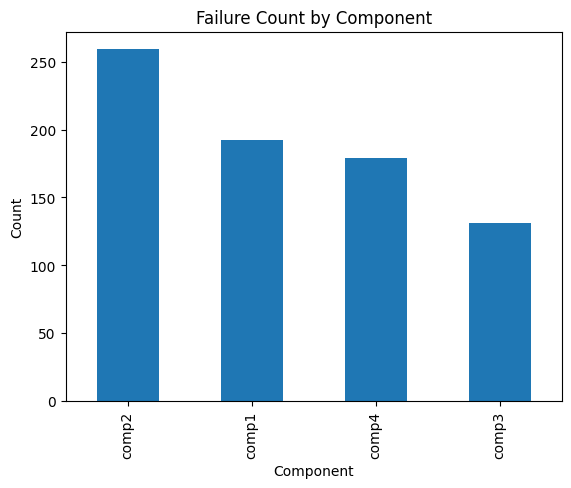

In [10]:
failure_counts = failures['failure'].value_counts()

plt.figure()
failure_counts.plot(kind='bar')
plt.title("Failure Count by Component")
plt.xlabel("Component")
plt.ylabel("Count")
plt.show()

4.2 Failures by Machine Model

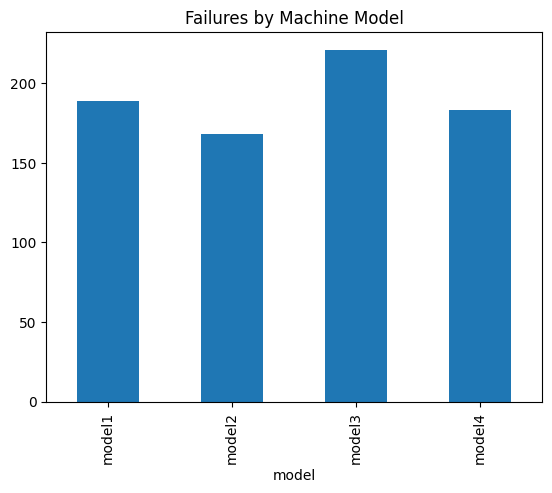

In [11]:
failure_model = failures.merge(machines, on="machine_id")
model_failures = failure_model.groupby("model").size()

plt.figure()
model_failures.plot(kind='bar')
plt.title("Failures by Machine Model")
plt.show()

4.3 Failures by Machine Age

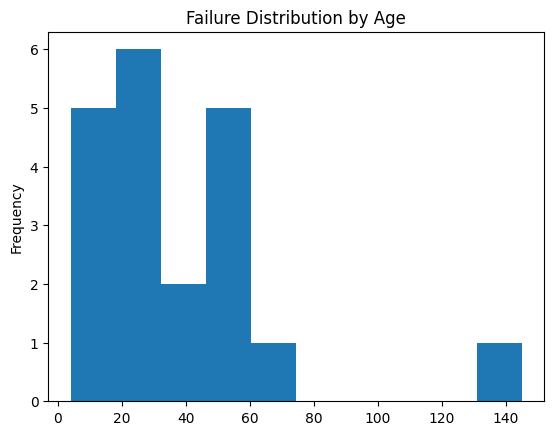

In [12]:
failure_model.groupby("age").size().plot(kind='hist', bins=10)
plt.title("Failure Distribution by Age")
plt.show()

STEP 5 — SENSOR BEHAVIOR BEFORE FAILURE

5.1 Merge telemetry with failures

In [13]:
data = telemetry.merge(failures, on=["machine_id", "datetime"], how="left")
data['is_failure'] = data['failure'].notnull().astype(int)

5.2 Compare sensor averages

In [14]:
data.groupby("is_failure")[["volt","rotate","pressure","vibration"]].mean()

,volt,rotate,pressure,vibration
is_failure,,,,
0,170.786596,446.621554,100.810169,40.384335
1,175.396873,419.764601,104.916120,43.174820


5.3 24-Hour Rolling Features

In [15]:
telemetry = telemetry.sort_values(["machine_id","datetime"])

telemetry["volt_roll24"] = telemetry.groupby("machine_id")["volt"].rolling(24).mean().reset_index(0,drop=True)
telemetry["vibration_roll24"] = telemetry.groupby("machine_id")["vibration"].rolling(24).mean().reset_index(0,drop=True)

STEP 6 — BUSINESS ANALYSIS

6.1 Maintenance Effectiveness

In [16]:
maint_count = maint.groupby("machine_id").size()
failure_count = failures.groupby("machine_id").size()

summary = pd.DataFrame({
    "maintenance_count": maint_count,
    "failure_count": failure_count
}).fillna(0)

summary.corr()

,maintenance_count,failure_count
maintenance_count,1.000000,-0.037616
failure_count,-0.037616,1.000000


6.2 Error Logs as Early Warning

In [17]:
error_count = errors.groupby("machine_id").size()

risk_summary = pd.DataFrame({
    "error_count": error_count,
    "failure_count": failure_count
}).fillna(0)

risk_summary.corr()

,error_count,failure_count
error_count,1.000000,0.537754
failure_count,0.537754,1.000000
